In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scanpy as sc
from starcat import starCAT
from scipy.stats import ttest_ind, fisher_exact, ranksums, wilcoxon
import sys
from statsmodels.stats.multitest import fdrcorrection
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

import requests
import openpyxl
import pandas as pd
import numpy as np
from io import BytesIO
from cnmf import cNMF
import scanpy as sc
from scipy.stats import ttest_rel
from sklearn.neighbors import NearestNeighbors
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import joblib
import os


sys.path.append('../../../Code')
from utils import read_dataset_log

In [2]:
from matplotlib import rcParams, font_manager
import matplotlib


rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [3]:
figdir = '../../../Figures/Components/Revision'

In [4]:
outdir = '../../../Data/Revision/BCC_Outcome'

# Download data

In [6]:
! mkdir -p ../../../Data/Revision/BCC_Outcome

In [9]:
! wget -O ../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.txt.gz https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fscc%5FscRNA%5Fcounts.txt.gz
! wget -O ../../../Data/Revision/BCC_Outcome/GSE123813_bcc_scRNA_counts.txt.gz https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fbcc%5FscRNA%5Fcounts.txt.gz

--2024-10-22 15:58:06--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fscc%5FscRNA%5Fcounts.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47514459 (45M) [application/x-gzip]
Saving to: ‘../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.txt.gz’

100%[======================================>] 47,514,459  7.10MB/s   in 6.5s   

2024-10-22 15:58:13 (6.94 MB/s) - ‘../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.txt.gz’ saved [47514459/47514459]

--2024-10-22 15:58:13--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fbcc%5FscRNA%5Fcounts.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 130.14.250.10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.n

In [10]:
! wget -O ../../../Data/Revision/BCC_Outcome/GSE123813_scc_metadata.txt.gz https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fscc%5Fmetadata.txt.gz
! wget -O ../../../Data/Revision/BCC_Outcome/GSE123813_bcc_all_metadata.txt.gz https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fbcc%5Fall%5Fmetadata.txt.gz

--2024-10-22 16:00:39--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fscc%5Fmetadata.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 130.14.250.13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 654637 (639K) [application/x-gzip]
Saving to: ‘../../../Data/Revision/BCC_Outcome/GSE123813_scc_metadata.txt.gz’

100%[======================================>] 654,637     2.65MB/s   in 0.2s   

2024-10-22 16:00:40 (2.65 MB/s) - ‘../../../Data/Revision/BCC_Outcome/GSE123813_scc_metadata.txt.gz’ saved [654637/654637]

--2024-10-22 16:00:40--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813%5Fbcc%5Fall%5Fmetadata.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 130.14.250.31, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.25

In [13]:
! gzip -d ../../../Data/Revision/BCC_Outcome/GSE123813_bcc_all_metadata.txt.gz
! gzip -d ../../../Data/Revision/BCC_Outcome/GSE123813_scc_metadata.txt.gz

In [23]:
! gzip -d ../../../Data/Revision/BCC_Outcome/GSE123813_bcc_scRNA_counts.txt.gz
! gzip -d ../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.txt.gz

In [21]:
! wget -O ../../../Data/Revision/BCC_Outcome/41591_2019_522_MOESM2_ESM.xlsx https://static-content.springer.com/esm/art%3A10.1038%2Fs41591-019-0522-3/MediaObjects/41591_2019_522_MOESM2_ESM.xlsx

--2024-10-22 16:15:25--  https://static-content.springer.com/esm/art%3A10.1038%2Fs41591-019-0522-3/MediaObjects/41591_2019_522_MOESM2_ESM.xlsx
Resolving static-content.springer.com (static-content.springer.com)... 151.101.64.95, 151.101.128.95, 151.101.192.95, ...
Connecting to static-content.springer.com (static-content.springer.com)|151.101.64.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2973899 (2.8M) [application/octet-stream]
Saving to: ‘../../../Data/Revision/BCC_Outcome/41591_2019_522_MOESM2_ESM.xlsx’

100%[======================================>] 2,973,899   11.6MB/s   in 0.2s   

2024-10-22 16:15:25 (11.6 MB/s) - ‘../../../Data/Revision/BCC_Outcome/41591_2019_522_MOESM2_ESM.xlsx’ saved [2973899/2973899]



In [22]:
! ls ../../../Data/Revision/BCC_Outcome/

41591_2019_522_MOESM2_ESM.xlsx	   GSE123813_scc_metadata.txt
GSE123813_bcc_all_metadata.txt	   GSE123813_scc_scRNA_counts.txt.gz
GSE123813_bcc_scRNA_counts.txt.gz


# Prepare matrices

In [25]:
bcc = pd.read_csv('../../../Data/Revision/BCC_Outcome/GSE123813_bcc_scRNA_counts.txt', sep='\t').T

In [94]:
bcc_meta = pd.read_csv('../../../Data/Revision/BCC_Outcome/GSE123813_bcc_all_metadata.txt', sep='\t')

In [95]:
bcc_meta.index = bcc_meta['cell.id']

In [96]:
obs = bcc_meta.loc[bcc.index, :]

In [97]:
obs.head()

,cell.id,patient,treatment,sort,cluster,UMAP1,UMAP2
bcc.su001.pre.tcell_AAACCTGCAGATCGGA,bcc.su001.pre.tcell_AAACCTGCAGATCGGA,su001,pre,CD45+ CD3+,CD4_T_cells,-4.893518,5.544943
bcc.su001.pre.tcell_AAACCTGCAGGGATTG,bcc.su001.pre.tcell_AAACCTGCAGGGATTG,su001,pre,CD45+ CD3+,CD4_T_cells,-5.255355,7.942832
bcc.su001.pre.tcell_AAACGGGCATAGACTC,bcc.su001.pre.tcell_AAACGGGCATAGACTC,su001,pre,CD45+ CD3+,Tregs,-1.279339,8.999942
bcc.su001.pre.tcell_AAACGGGTCATACGGT,bcc.su001.pre.tcell_AAACGGGTCATACGGT,su001,pre,CD45+ CD3+,CD8_mem_T_cells,-0.192800,4.358763
bcc.su001.pre.tcell_AAACGGGTCATAGCAC,bcc.su001.pre.tcell_AAACGGGTCATAGCAC,su001,pre,CD45+ CD3+,CD4_T_cells,-3.719776,8.670669


In [98]:
adata_bcc = sc.AnnData(X=sp.csr_matrix(bcc.values), obs=obs, var=pd.DataFrame(bcc.columns, index=bcc.columns, columns=['Gene']))

In [99]:
adata_bcc.write('../../../Data/Revision/BCC_Outcome/GSE123813_bcc_scRNA_counts.h5ad')

In [100]:
adata_bcc.obs.head()

,cell.id,patient,treatment,sort,cluster,UMAP1,UMAP2
bcc.su001.pre.tcell_AAACCTGCAGATCGGA,bcc.su001.pre.tcell_AAACCTGCAGATCGGA,su001,pre,CD45+ CD3+,CD4_T_cells,-4.893518,5.544943
bcc.su001.pre.tcell_AAACCTGCAGGGATTG,bcc.su001.pre.tcell_AAACCTGCAGGGATTG,su001,pre,CD45+ CD3+,CD4_T_cells,-5.255355,7.942832
bcc.su001.pre.tcell_AAACGGGCATAGACTC,bcc.su001.pre.tcell_AAACGGGCATAGACTC,su001,pre,CD45+ CD3+,Tregs,-1.279339,8.999942
bcc.su001.pre.tcell_AAACGGGTCATACGGT,bcc.su001.pre.tcell_AAACGGGTCATACGGT,su001,pre,CD45+ CD3+,CD8_mem_T_cells,-0.192800,4.358763
bcc.su001.pre.tcell_AAACGGGTCATAGCAC,bcc.su001.pre.tcell_AAACGGGTCATAGCAC,su001,pre,CD45+ CD3+,CD4_T_cells,-3.719776,8.670669


In [102]:
outcome_data = pd.ExcelFile('../../../Data/Revision/BCC_Outcome/41591_2019_522_MOESM2_ESM.xlsx').parse('SuppTable1', skiprows=3)
outcome_data = outcome_data.drop(15, axis=0)
outcome_data.index = outcome_data['Patient'].values
outcome_data

,Patient,Tumor Type,Treatment,Ongoing Vismodegib treatment,Prior treatment,Response,Best % change,scRNA pre site,scRNA days pre treatment,scRNA post site,...,Adaptive pre site,Adaptive days pre treatment,Adaptive post site,Adaptive days post treatment,PBMC Adaptive days pre treatment,PBMC Adaptive days post treatment,Exome pre site,Exome days pre treatment,Exome post site,Exome days post treatment
su001,su001,BCC,Pembrolizumab,+,Vismodegib,Yes,-81,L arm,"-239, -78",L arm,...,L arm,"-78, -5",L arm,"83, 146",-239.0,104.0,L arm,-78.0,L arm,146.0
su002,su002,BCC,Pembrolizumab,-,Vismodegib,Yes,0*,Nose,0,Nose,...,Nose,-602,NaN,NaN,NaN,117.0,Nose,0.0,Nose,62.0
su003,su003,BCC,Pembrolizumab,-,Vismodegib,Yes,-100,R arm,-243,R chest,...,NaN,NaN,R chest,15,-243.0,16.0,R arm,-244.0,R arm,155.0
su004,su004,BCC,Cemiplimab,-,-,Yes,-25,Knee,1,Knee,...,NaN,NaN,NaN,NaN,NaN,NaN,Knee,0.0,NaN,NaN
su005,su005,BCC,Pembrolizumab,-,Vismodegib,No,5,L ear,0,L ear,...,L ear,-28,L ear,42,0.0,42.0,L ear,0.0,L ear,105.0
su006,su006,BCC,Pembrolizumab,+,Vismodegib,No,-11,R neck,0,R neck,...,R neck,-280,R neck,140,-84.0,140.0,R neck,-79.0,R neck,21.0
su007,su007,BCC,Pembrolizumab,-,Vismodegib,No,10,L cheek,-3,L cheek,...,L cheek,-3,L cheek,60,-1855.0,39.0,L cheek,-3.0,L cheek,60.0
su008,su008,BCC,Pembrolizumab,+,Vismodegib,No,0,R arm,-91,R arm,...,R arm,-43,R arm,42,-98.0,43.0,NaN,NaN,R arm,43.0
su009,su009,BCC,Cemiplimab,-,Sonidegib,Yes,-62,L forehead,0,L forehead,...,L forehead,0,L forehead,21,NaN,NaN,NaN,NaN,NaN,NaN
su010-S,su010-S,SCC,Pembrolizumab,-,-,Yes,-100,L ear,-6,L ear,...,L ear,-12,L ear,21,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
merge = pd.merge(left=adata_bcc.obs, right=outcome_data[['Tumor Type', 'Treatment', 'Prior treatment', 'Response', 'Best % change', 'scRNA pre site', 'scRNA days pre treatment',
                                                'scRNA post site', 'scRNA days post treatment']], how='left', left_on='patient', right_index=True)
merge.head()

,cell.id,patient,treatment,sort,cluster,UMAP1,UMAP2,Tumor Type,Treatment,Prior treatment,Response,Best % change,scRNA pre site,scRNA days pre treatment,scRNA post site,scRNA days post treatment
bcc.su001.pre.tcell_AAACCTGCAGATCGGA,bcc.su001.pre.tcell_AAACCTGCAGATCGGA,su001,pre,CD45+ CD3+,CD4_T_cells,-4.893518,5.544943,BCC,Pembrolizumab,Vismodegib,Yes,-81,L arm,"-239, -78",L arm,83
bcc.su001.pre.tcell_AAACCTGCAGGGATTG,bcc.su001.pre.tcell_AAACCTGCAGGGATTG,su001,pre,CD45+ CD3+,CD4_T_cells,-5.255355,7.942832,BCC,Pembrolizumab,Vismodegib,Yes,-81,L arm,"-239, -78",L arm,83
bcc.su001.pre.tcell_AAACGGGCATAGACTC,bcc.su001.pre.tcell_AAACGGGCATAGACTC,su001,pre,CD45+ CD3+,Tregs,-1.279339,8.999942,BCC,Pembrolizumab,Vismodegib,Yes,-81,L arm,"-239, -78",L arm,83
bcc.su001.pre.tcell_AAACGGGTCATACGGT,bcc.su001.pre.tcell_AAACGGGTCATACGGT,su001,pre,CD45+ CD3+,CD8_mem_T_cells,-0.192800,4.358763,BCC,Pembrolizumab,Vismodegib,Yes,-81,L arm,"-239, -78",L arm,83
bcc.su001.pre.tcell_AAACGGGTCATAGCAC,bcc.su001.pre.tcell_AAACGGGTCATAGCAC,su001,pre,CD45+ CD3+,CD4_T_cells,-3.719776,8.670669,BCC,Pembrolizumab,Vismodegib,Yes,-81,L arm,"-239, -78",L arm,83


In [104]:
merge['Tumor Type'].value_counts()

Tumor Type
BCC    53030
Name: count, dtype: int64

In [105]:
adata_bcc.obs = merge

In [106]:
adata_bcc.obs['scRNA days post treatment'] = adata_bcc.obs['scRNA days post treatment'].astype(str)
adata_bcc.obs['scRNA days pre treatment'] = adata_bcc.obs['scRNA days pre treatment'].astype(str)
adata_bcc.obs['Best % change'] = adata_bcc.obs['Best % change'].astype(str)

In [107]:
adata_bcc.write('../../../Data/Revision/BCC_Outcome/GSE123813_bcc_scRNA_counts.h5ad')

In [108]:
scc = pd.read_csv('../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.txt', sep='\t').T

In [114]:
scc_meta = pd.read_csv('../../../Data/Revision/BCC_Outcome/GSE123813_scc_metadata.txt', sep='\t')
scc_meta.head()

,cell.id,patient,treatment,cluster,UMAP1,UMAP2
0,scc.su010.post_AAACCTGAGACAAAGG,su010,post,CD8_mem,-2.155080,1.904121
1,scc.su010.post_AAACCTGAGACTAAGT,su010,post,CD8_ex,-1.547080,-1.710866
2,scc.su010.post_AAACCTGAGGCATGGT,su010,post,CD8_mem,-0.820249,0.311856
3,scc.su010.post_AAACCTGAGGGTCGAT,su010,post,Naive,2.743202,0.647236
4,scc.su010.post_AAACCTGAGGTACTCT,su010,post,Tfh,2.759312,0.526145


In [115]:
scc_meta.index = scc_meta['cell.id']

In [116]:
obs = scc_meta.loc[scc.index, :]

In [117]:
obs.head()

,cell.id,patient,treatment,cluster,UMAP1,UMAP2
scc.su010.pre.rep1_AAACCTGCATGTTCCC,scc.su010.pre.rep1_AAACCTGCATGTTCCC,su010,pre,CD8_naive,-5.055816,3.093178
scc.su010.pre.rep1_AAACGGGAGGACAGAA,scc.su010.pre.rep1_AAACGGGAGGACAGAA,su010,pre,CD8_naive,-4.361540,2.970602
scc.su010.pre.rep1_AAACGGGCAAGTCTAC,scc.su010.pre.rep1_AAACGGGCAAGTCTAC,su010,pre,Th17,2.955230,-4.796993
scc.su010.pre.rep1_AAACGGGGTAGTACCT,scc.su010.pre.rep1_AAACGGGGTAGTACCT,su010,pre,CD8_naive,-4.597772,2.647269
scc.su010.pre.rep1_AAACGGGGTGATAAAC,scc.su010.pre.rep1_AAACGGGGTGATAAAC,su010,pre,CD8_naive,-3.909451,3.647786


In [118]:
adata_scc = sc.AnnData(X=sp.csr_matrix(scc.values), obs=obs, var=pd.DataFrame(scc.columns, index=scc.columns, columns=['Gene']))

In [125]:
adata_scc.obs['patient'] = adata_scc.obs['patient'].replace({'su010': 'su010-S'})

In [126]:
adata_scc.write('../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.h5ad')

In [127]:
adata_scc.obs['patient'].value_counts()

patient
su010-S    10475
su011       7552
su013       4557
su014       3432
Name: count, dtype: int64

In [128]:
merge = pd.merge(left=adata_scc.obs, right=outcome_data[['Tumor Type', 'Treatment', 'Prior treatment', 'Response', 'Best % change', 'scRNA pre site', 'scRNA days pre treatment',
                                                'scRNA post site', 'scRNA days post treatment']], how='left', left_on='patient', right_index=True)
merge.head()

,cell.id,patient,treatment,cluster,UMAP1,UMAP2,Tumor Type,Treatment,Prior treatment,Response,Best % change,scRNA pre site,scRNA days pre treatment,scRNA post site,scRNA days post treatment
scc.su010.pre.rep1_AAACCTGCATGTTCCC,scc.su010.pre.rep1_AAACCTGCATGTTCCC,su010-S,pre,CD8_naive,-5.055816,3.093178,SCC,Pembrolizumab,-,Yes,-100,L ear,-6,L ear,21
scc.su010.pre.rep1_AAACGGGAGGACAGAA,scc.su010.pre.rep1_AAACGGGAGGACAGAA,su010-S,pre,CD8_naive,-4.361540,2.970602,SCC,Pembrolizumab,-,Yes,-100,L ear,-6,L ear,21
scc.su010.pre.rep1_AAACGGGCAAGTCTAC,scc.su010.pre.rep1_AAACGGGCAAGTCTAC,su010-S,pre,Th17,2.955230,-4.796993,SCC,Pembrolizumab,-,Yes,-100,L ear,-6,L ear,21
scc.su010.pre.rep1_AAACGGGGTAGTACCT,scc.su010.pre.rep1_AAACGGGGTAGTACCT,su010-S,pre,CD8_naive,-4.597772,2.647269,SCC,Pembrolizumab,-,Yes,-100,L ear,-6,L ear,21
scc.su010.pre.rep1_AAACGGGGTGATAAAC,scc.su010.pre.rep1_AAACGGGGTGATAAAC,su010-S,pre,CD8_naive,-3.909451,3.647786,SCC,Pembrolizumab,-,Yes,-100,L ear,-6,L ear,21


In [129]:
merge['Tumor Type'].value_counts()

Tumor Type
SCC    26016
Name: count, dtype: int64

In [130]:
adata_scc.obs = merge

In [131]:
adata_scc.obs['scRNA days post treatment'] = adata_scc.obs['scRNA days post treatment'].astype(str)
adata_scc.obs['scRNA days pre treatment'] = adata_scc.obs['scRNA days pre treatment'].astype(str)
adata_scc.obs['Best % change'] = adata_scc.obs['Best % change'].astype(str)

In [132]:
adata_scc.write('../../../Data/Revision/BCC_Outcome/GSE123813_scc_scRNA_counts.h5ad')

In [133]:
adata_scc

AnnData object with n_obs × n_vars = 26016 × 18347
    obs: 'cell.id', 'patient', 'treatment', 'cluster', 'UMAP1', 'UMAP2', 'Tumor Type', 'Treatment', 'Prior treatment', 'Response', 'Best % change', 'scRNA pre site', 'scRNA days pre treatment', 'scRNA post site', 'scRNA days post treatment'
    var: 'Gene'

In [136]:
adata_bcc.obs['sort'].value_counts()

sort
CD45+ CD3+    32536
CD3-          10569
CD45+ CD3-     4622
CD45- CD3-     4394
Name: count, dtype: int64

In [139]:
pd.crosstab(adata_bcc.obs['patient'], adata_bcc.obs['sort'])

sort,CD3-,CD45+ CD3+,CD45+ CD3-,CD45- CD3-
patient,,,,
su001,6575,4832,0,0
su002,27,178,0,0
su003,0,231,0,482
su004,646,873,0,0
su005,1464,3355,1047,643
su006,0,3797,3168,2293
su007,477,1448,0,0
su008,1380,4809,407,976
su009,0,9054,0,0


In [141]:
adata_scc.obs['patient'].value_counts()

patient
su010-S    10475
su011       7552
su013       4557
su014       3432
Name: count, dtype: int64

In [138]:
pd.crosstab(adata_bcc.obs['sort'], adata_bcc.obs['cluster']).T

sort,CD3-,CD45+ CD3+,CD45+ CD3-,CD45- CD3-
cluster,,,,
B_cells_1,5680,32,106,3
B_cells_2,193,0,1,0
CAFs,448,8,20,555
CD4_T_cells,32,7579,9,1
CD8_act_T_cells,62,4096,6,1
CD8_ex_T_cells,1,3693,1,0
CD8_mem_T_cells,96,11604,95,3
DCs,263,18,179,1
Endothelial,156,3,0,273


In [264]:
adata_scc.obs['sort'] = 'CD45+ CD3+'
adata_scc.obs = adata_scc.obs[adata_bcc.obs.columns]

In [265]:
adata_combined = adata_bcc.concatenate(adata_scc)

/tmp/ipykernel_154827/4266285785.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_bcc.concatenate(adata_scc)


In [378]:
adata_combined.obs['sample'] = adata_combined.obs['patient'].astype(str) + '_' + adata_combined.obs['treatment'].astype(str)
adata_combined.obs['Response'] = adata_combined.obs['Response'].replace({'Yes':'Responder', 'No':'Non-responder', 'Yes (CR)':'Responder'})
adata_combined.obs = adata_combined.obs.rename(columns={'Response':'response', 'treatment':'timepoint'})
adata_combined.obs['timepoint'] = adata_combined.obs['timepoint'].replace({'pre':'Pre', 'post':'Post'})


In [379]:
adata_combined.write('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.h5ad')

# Re-cluster

In [380]:
adata = sc.read('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.h5ad')

In [381]:
adata

AnnData object with n_obs × n_vars = 79046 × 18189
    obs: 'cell.id', 'patient', 'timepoint', 'sort', 'cluster', 'UMAP1', 'UMAP2', 'Tumor Type', 'Treatment', 'Prior treatment', 'response', 'Best % change', 'scRNA pre site', 'scRNA days pre treatment', 'scRNA post site', 'scRNA days post treatment', 'batch', 'sample'
    var: 'Gene'

In [382]:
sc.pp.filter_genes(adata, min_cells=10)

In [383]:
adata.shape

(79046, 17981)

In [384]:
adata.X = adata.X.astype(np.float64)

In [385]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

In [386]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e6)

In [387]:
sc.pp.log1p(adata)

In [388]:
sc.pp.pca(adata, mask_var='highly_variable')

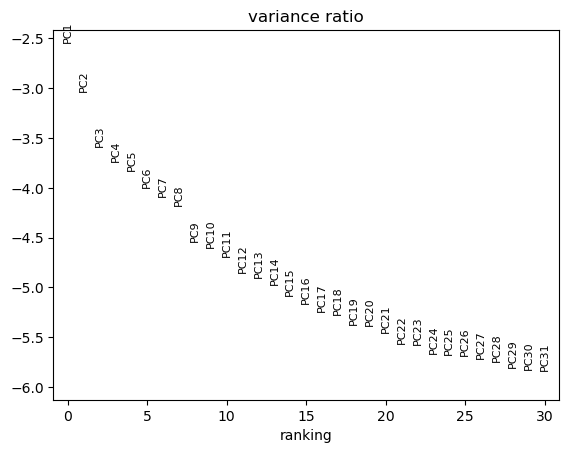

In [389]:
sc.pl.pca_variance_ratio(adata, log=True)

In [390]:
sc.external.pp.harmony_integrate(adata, key=['Tumor Type', 'sample'])

2024-10-22 18:49:47,282 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-10-22 18:49:59,889 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-10-22 18:50:00,256 - harmonypy - INFO - Iteration 1 of 10
2024-10-22 18:50:37,418 - harmonypy - INFO - Iteration 2 of 10
2024-10-22 18:51:14,965 - harmonypy - INFO - Converged after 2 iterations


In [391]:
sc.pp.neighbors(adata, n_pcs=29, n_neighbors=20, use_rep='X_pca_harmony')

In [392]:
sc.tl.umap(adata)

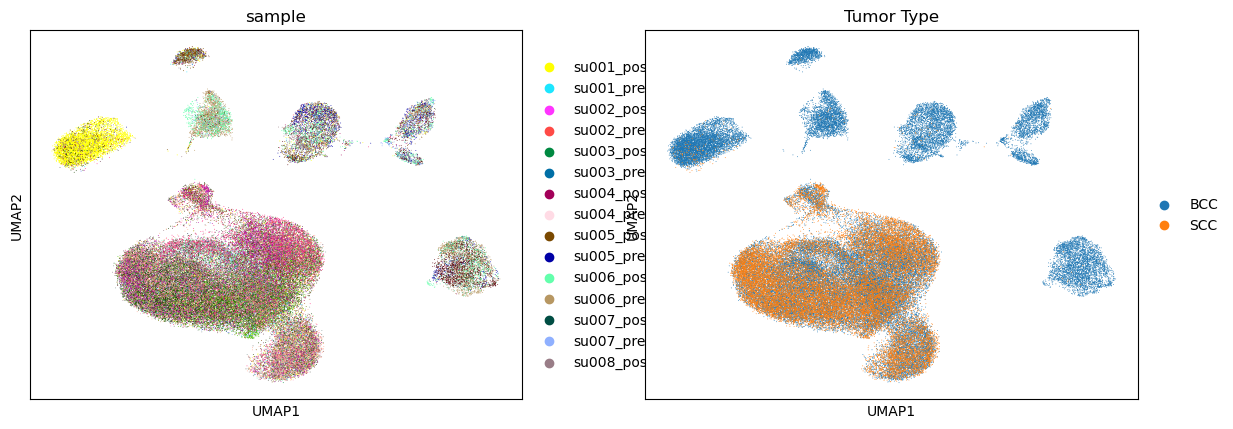

In [393]:
sc.pl.umap(adata, color=['sample', 'Tumor Type'])

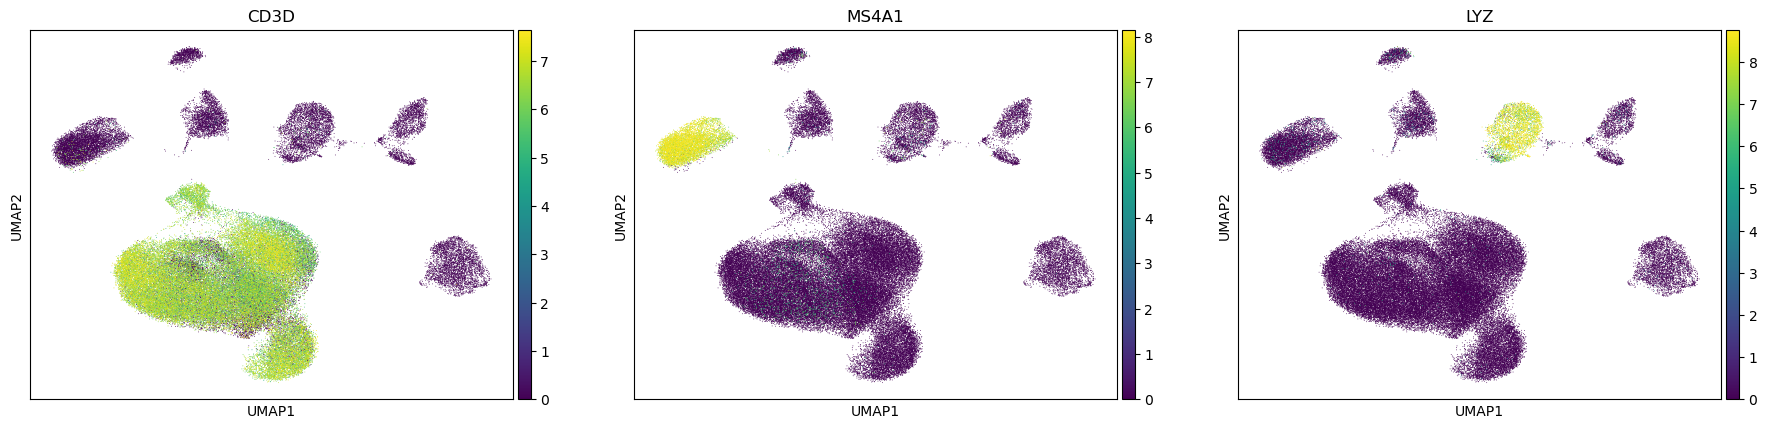

In [394]:
sc.pl.umap(adata, color=['CD3D', 'MS4A1', 'LYZ'], vmax='p99')

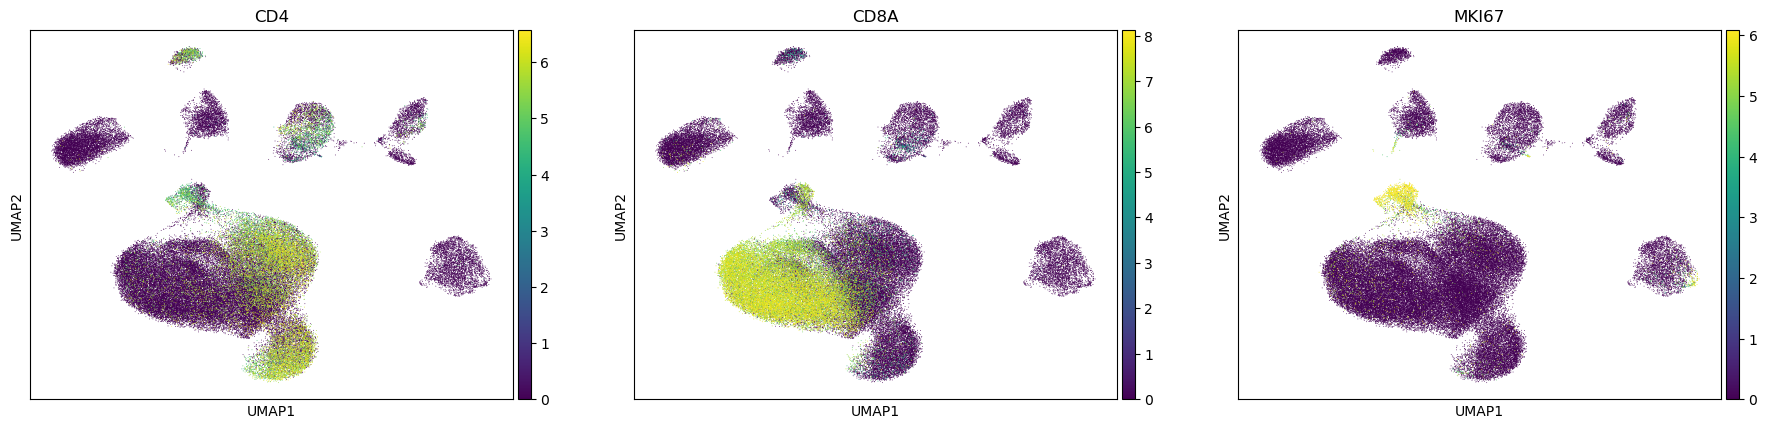

In [395]:
sc.pl.umap(adata, color=['CD4', 'CD8A', 'MKI67'], vmax='p99')

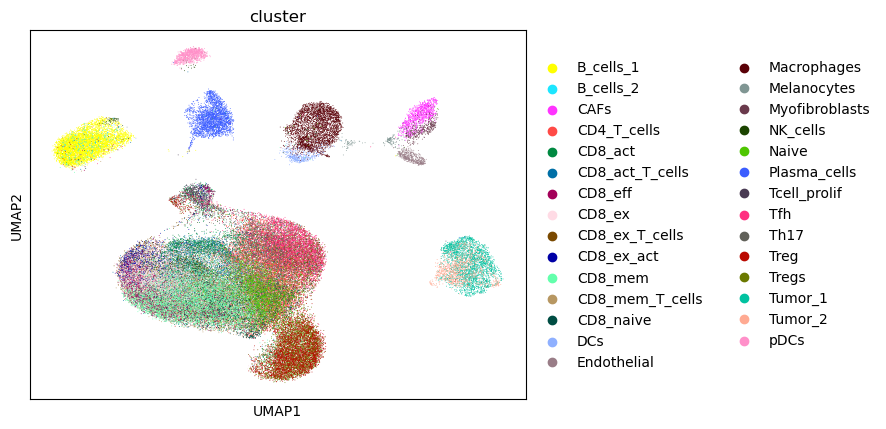

In [396]:
sc.pl.umap(adata, color=['cluster'], vmax='p99')

In [397]:
sc.tl.leiden(adata, resolution=1.0)

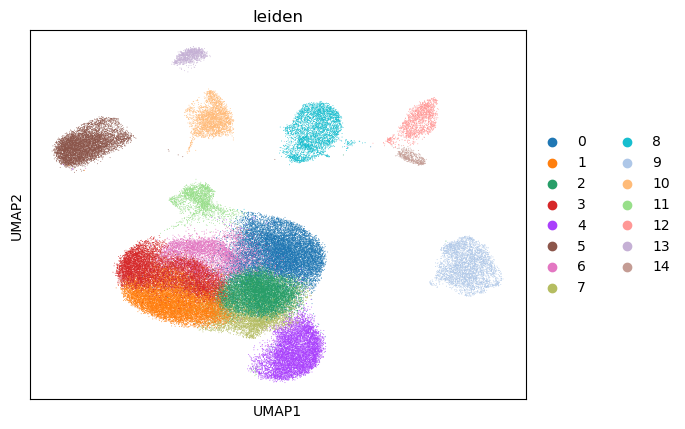

In [398]:
sc.pl.umap(adata, color=['leiden'])

In [399]:
sc.tl.rank_genes_groups(adata, groupby='leiden')

In [400]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,SPOCK2,CCL5,IL7R,CCL5,FOXP3,HLA-DRA,DNAJB1,MT-CO1,CST3,PERP,MZB1,STMN1,IFITM3,CD74,IFITM3
1,TNFRSF18,CST7,ANXA1,NKG7,IL32,MS4A1,HSPA1B,MT-ND3,TYROBP,KRT17,SSR4,HMGB2,LGALS1,HLA-DRA,IGFBP7
2,CD2,GZMK,SARAF,GZMB,BATF,HLA-DQA1,HSPA1A,MALAT1,LYZ,KRT5,FKBP11,HMGN2,SPARC,TYROBP,VIM
3,CD3E,NKG7,RPS27,GNLY,TNFRSF4,HLA-DRB5,DUSP1,MT-CO2,HLA-DRA,KRT14,DERL3,TUBB,CD63,SEC61B,TM4SF1
4,SRGN,CD8A,CXCR4,CST7,TNFRSF18,HLA-DRB1,HSPA8,MT-CYB,SAT1,S100A14,CD79A,HMGB1,CALD1,GZMB,CRIP2
5,TNFRSF4,RPS27,RPL41,CTSW,TIGIT,HLA-DQB1,UBC,MT-ATP6,LGALS1,DSP,PRDX4,TUBA1B,VIM,JCHAIN,CST3
6,CXCL13,DUSP2,RPS12,PRF1,CARD16,HLA-DPB1,HSPA6,IL7R,VIM,CD9,XBP1,H2AFZ,CST3,TCF4,GNG11
7,B2M,HLA-B,ZFP36L2,CD8A,CD7,HLA-DPA1,HSP90AA1,MT-CO3,SPI1,ACTG1,IGKC,ANP32B,COL6A1,TSPAN13,SPARC
8,IL32,PTPRC,SPOCK2,GZMH,TBC1D4,CD74,PPP1R15A,PTPRC,HLA-DRB5,S100A2,HERPUD1,COX8A,COL6A2,GPR183,IFI27
9,S100A4,CXCR4,RPS29,AC092580.4,SPOCK2,CD79A,UBB,MTRNR2L12,FCER1G,KRT15,IGHG4,CALM3,COL1A2,IGKC,IFITM2


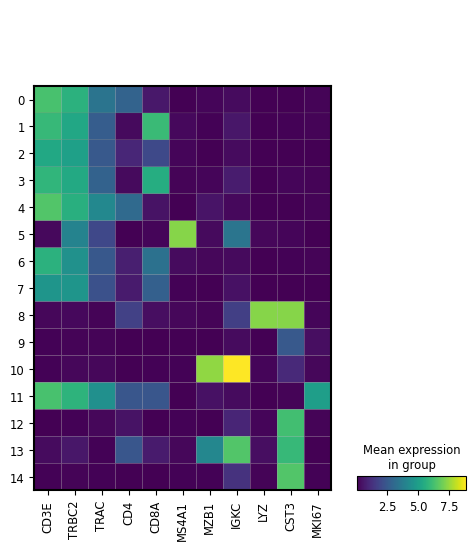

In [401]:
sc.pl.matrixplot(adata, groupby='leiden', var_names=['CD3E', 'TRBC2', 'TRAC', 'CD4', 'CD8A', 'MS4A1', 'MZB1', 'IGKC', 'LYZ', 'CST3', 'MKI67'])

In [402]:
mapping = {
    0 : 'T.1',
    1 : 'T.2',
    2 : 'T.3',
    3 : 'T.4',
    4 : 'T.5',
    5 : 'B.1',
    6 : 'T.6',
    7 : 'T.7',
    8 : 'Myeloid.1',
    9 : 'Myeloid.2',
    10 : 'B.2',
    11 : 'T.8',
    12 : 'Myeloid.3',
    13 : 'Myeloid.4',
    14 : 'Myeloid.5',
}

adata.obs['leiden_labeled'] = adata.obs['leiden'].astype(int).replace(mapping)
adata.obs['leiden_labeled_reduced'] = adata.obs['leiden_labeled'].apply(lambda x: x.split('.')[0])

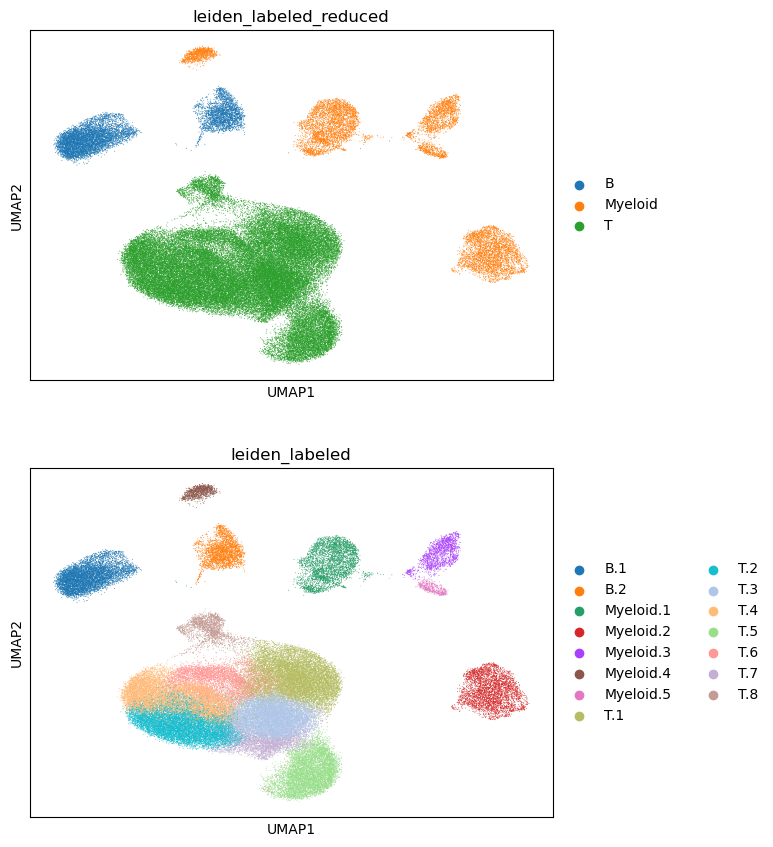

In [403]:
sc.pl.umap(adata, color=['leiden_labeled_reduced', 'leiden_labeled'], ncols=1)

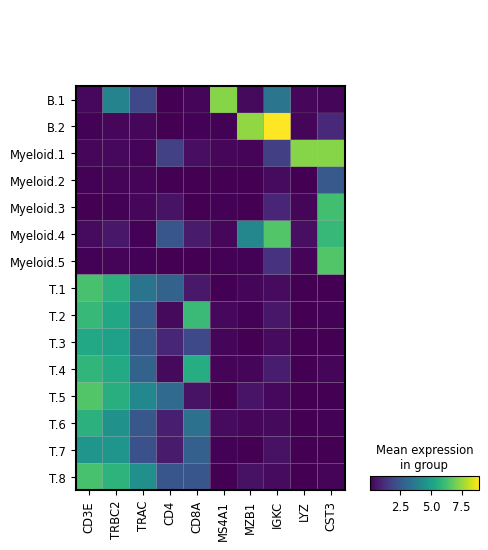

In [404]:
sc.pl.matrixplot(adata, groupby='leiden_labeled', var_names=['CD3E', 'TRBC2', 'TRAC', 'CD4', 'CD8A', 'MS4A1', 'MZB1', 'IGKC', 'LYZ', 'CST3'])

In [405]:
sc.tl.rank_genes_groups(adata, groupby='leiden_labeled')

In [406]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(20)

,B.1,B.2,Myeloid.1,Myeloid.2,Myeloid.3,Myeloid.4,Myeloid.5,T.1,T.2,T.3,T.4,T.5,T.6,T.7,T.8
0,HLA-DRA,MZB1,CST3,PERP,IFITM3,CD74,IFITM3,SPOCK2,CCL5,IL7R,CCL5,FOXP3,DNAJB1,MT-CO1,STMN1
1,MS4A1,SSR4,TYROBP,KRT17,LGALS1,HLA-DRA,IGFBP7,TNFRSF18,CST7,ANXA1,NKG7,IL32,HSPA1B,MT-ND3,HMGB2
2,HLA-DQA1,FKBP11,LYZ,KRT5,SPARC,TYROBP,VIM,CD2,GZMK,SARAF,GZMB,BATF,HSPA1A,MALAT1,HMGN2
3,HLA-DRB5,DERL3,HLA-DRA,KRT14,CD63,SEC61B,TM4SF1,CD3E,NKG7,RPS27,GNLY,TNFRSF4,DUSP1,MT-CO2,TUBB
4,HLA-DRB1,CD79A,SAT1,S100A14,CALD1,GZMB,CRIP2,SRGN,CD8A,CXCR4,CST7,TNFRSF18,HSPA8,MT-CYB,HMGB1
5,HLA-DQB1,PRDX4,LGALS1,DSP,VIM,JCHAIN,CST3,TNFRSF4,RPS27,RPL41,CTSW,TIGIT,UBC,MT-ATP6,TUBA1B
6,HLA-DPB1,XBP1,VIM,CD9,CST3,TCF4,GNG11,CXCL13,DUSP2,RPS12,PRF1,CARD16,HSPA6,IL7R,H2AFZ
7,HLA-DPA1,IGKC,SPI1,ACTG1,COL6A1,TSPAN13,SPARC,B2M,HLA-B,ZFP36L2,CD8A,CD7,HSP90AA1,MT-CO3,ANP32B
8,CD74,HERPUD1,HLA-DRB5,S100A2,COL6A2,GPR183,IFI27,IL32,PTPRC,SPOCK2,GZMH,TBC1D4,PPP1R15A,PTPRC,COX8A
9,CD79A,IGHG4,FCER1G,KRT15,COL1A2,IGKC,IFITM2,S100A4,CXCR4,RPS29,AC092580.4,SPOCK2,UBB,MTRNR2L12,CALM3


In [407]:
adata.write('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA.logTPM.clustered.h5ad')

In [408]:
pd.crosstab(adata.obs['cluster'].rename('Published cluster'), adata.obs['leiden_labeled_reduced'].rename('Our cluster'))

Our cluster,B,Myeloid,T
Published cluster,,,
B_cells_1,5827,2,0
B_cells_2,194,0,0
CAFs,1,1065,0
CD4_T_cells,3,2,7760
CD8_act,2,7,1263
CD8_act_T_cells,5,2,4191
CD8_eff,1,1,1030
CD8_ex,64,6,4079
CD8_ex_T_cells,3,1,3732


In [5]:
adata.obs['sort'].value_counts()

sort
CD45+ CD3+    58552
CD3-          10569
CD45+ CD3-     4622
CD45- CD3-     4394
Name: count, dtype: int64

# Run TCAT

In [5]:
adata_raw = sc.read('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.h5ad')

In [6]:
adata = sc.read('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA.logTPM.clustered.h5ad')

Only considering the two last: ['.clustered', '.h5ad'].
Only considering the two last: ['.clustered', '.h5ad'].


In [7]:
adata_raw.obs.index == adata.obs.index

array([ True,  True,  True, ...,  True,  True,  True])

In [8]:
adata = adata_raw[adata.obs[ 'leiden_labeled_reduced']=='T', :]

In [9]:
adata.write('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.h5ad')

In [93]:
adata = sc.read('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.h5ad')

In [94]:
sc.pp.filter_genes(adata, min_cells=10)

In [95]:
adata.obs['sort'].astype(str).replace(np.nan, 'null').value_counts()

sort
CD45+ CD3+    58078
CD3-           1015
nan             535
CD45+ CD3-      234
CD45- CD3-       10
Name: count, dtype: int64

In [96]:
tcat = starCAT(reference='TCAT.V1', cachedir='../../../Data/Revision/BCC_Outcome/tcat_cache')

Using reference from starCAT database
Loading reference from existing cache file for reference TCAT.V1


In [97]:
usage, scores = tcat.fit_transform(adata)

3165 out of 3412 genes in the reference overlap with the query


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.0.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [98]:
usage.to_csv('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.TCAT.Usage.tsv', sep='\t')
scores.to_csv('../../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.TCAT.Scores.tsv', sep='\t')

In [99]:
for s in scores:
    adata.obs[s] = scores[s]

In [100]:
pd.crosstab(adata.obs['cluster'], adata.obs['Multinomial_Label'])

Multinomial_Label,CD4_CM,CD4_EM,CD4_Naive,CD8_CM,CD8_EM,CD8_Naive,CD8_TEMRA,MAIT,Treg,gdT
cluster,,,,,,,,,,
CD4_T_cells,3802,2290,1273,144,7,91,12,117,15,9
CD8_act,188,140,352,161,77,84,154,2,28,77
CD8_act_T_cells,543,832,312,645,494,253,848,54,3,207
CD8_eff,32,161,16,472,189,94,51,5,0,10
CD8_ex,68,70,219,1817,157,1225,298,6,1,218
CD8_ex_T_cells,1650,428,417,604,33,287,220,13,12,68
CD8_ex_act,3,41,21,342,47,47,36,1,5,71
CD8_mem,276,401,247,1012,486,1709,745,27,1,374
CD8_mem_T_cells,1643,1527,549,2266,1319,1914,1956,135,0,695


# Associated GEPs

In [120]:
import os

def run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder'):
    ttest_res = []
    for v in variables:
        T,P = ttest_ind(rdat.loc[rdat[feature]==g1lab, v], rdat.loc[rdat[feature]==g2lab, v],
                        equal_var=False)
        meandiff = rdat.loc[rdat[feature]==g1lab, v].mean() - rdat.loc[rdat[feature]==g2lab, v].mean()
        #T,P = ranksums(rdat.loc[rdat['response']=='Non-responder', v], rdat.loc[rdat['response']=='Responder', v])
        ttest_res.append([v, T, P, meandiff])

    ttest_res = pd.DataFrame(ttest_res, columns=['GEP', 'T', 'P', 'Delta'])
    ttest_res.index = ttest_res['GEP']

    _, ttest_res.loc[:, 'Q'] =  fdrcorrection(ttest_res.loc[:, 'P'])

    ttest_res['logP'] = ttest_res['P'].apply(np.log10)*-1
    ttest_res['logQ'] = ttest_res['Q'].apply(np.log10)*-1

    ttest_res['signed_logP'] = ttest_res['T'].apply(np.sign)*ttest_res['logP']
    return(ttest_res)
    

In [121]:
sample_data = sample_info

In [122]:
melanoma_pos = ['CellCycle-G2M', 'HLA', 'ISG', 'CellCycle-S', 'NME1/FABP5',
       'CellCycle-Late-S', 'Cytoskeleton', 'Metallothionein', 'TIMD4/TIM3',
       'ICOS/CD38', 'OX40/EBI3', 'Tph', 'Exhaustion']

melanoma_neg = ['CD4-Naive']

melanoma_un = ['Translation', 'Mito', 'Doublet-RBC', 'gdT', 'Cytotoxic',
       'Doublet-Platelet', 'Th22', 'MAIT', 'Heatshock', 'Multi-Cytokine',
       'TEMRA', 'Doublet-Myeloid', 'CD4-CM', 'IEG', 'CD8-EM', 'IEG2', 'Treg',
       'Th17-Resting', 'Poor-Quality', 'CD8-Naive', 'RGCC/MYADM',
       'Doublet-Plasmablast', 'BCL2/FAM13A', 'IL10/IL19', 'Th2-Activated',
       'Th2-Resting', 'Doublet-Bcell', 'Th1-Like', 'CTLA4/CD38', 'CD8-Trm',
       'Th17-Activated', 'Tfh-2', 'CD172a/MERTK', 'IEG3', 'Doublet-Fibroblast',
       'SOX4/TOX2', 'CD40LG/TXNIP', 'Tfh-1']

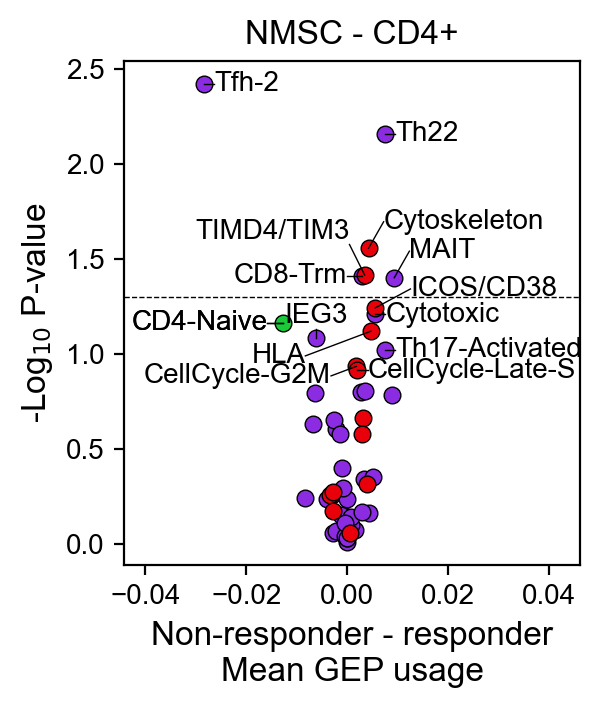

In [151]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM', 'CD4_TEMRA']) & (adata.obs['sort'].astype(str)=='CD45+ CD3+')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_data.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'cell.id'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>4, :]

r = 'Both'
rdat = allcell_act_pct_merged.copy()
ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.96, 'bottom':.23, 'top':.86})

ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)

ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])
ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0]-.2, xmax=xlim[1]+.2, linestyle='--', zorder=-5, color='k', lw=.5)
ax.set_xlim(xlim)

X = ttest_res.sort_values(by='P')
geps_to_plot = list(X.index[X['P']<.11]) + ['CD4-Naive', 'CellCycle-G2M', 'CellCycle-Late-S']

xval = 'Delta'
yval = 'logP'
fs = 10


for i,g in enumerate(geps_to_plot):
    #lab = shorten_map[g]
    lab = g


    
    if g in [ 'CD8-Trm', 'CD4-Naive']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['CTLA4/CD38']: deltax = -.01; deltay = 0.03; ha='right'; va='center' ## Left
    elif g in ['Cytoskeleton', 'MAIT']: deltax = .003; deltay = .14; ha='left'; va='center' ## Upper-right
    elif g in ['ICOS/CD38']: deltax = .007; deltay = .1; ha='left'; va='center' ## Upper-right

    elif g in []: deltax = 0.02; deltay = -.3; ha='center'; va='top' ## Lower-right
    elif g in [ 'HLA',]: deltax = -0.013; deltay =-0.13; ha='right'; va='center' ## Lower-Left
    elif g in ['CellCycle-G2M', ]: deltax = -0.005; deltay =-0.05; ha='right'; va='center' ## Lower-Left

    elif g in [ 'IEG3']: deltax = 0.00; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in []: deltax = 0.003; deltay =-0.1; ha='center'; va='top' ## Below

    elif g in ['TIMD4/TIM3',]: deltax = -0.003; deltay =0.16; ha='right'; va='bottom' ## Upper-Left
    elif g in ['Th2-Activated', ]: deltax = -0.003; deltay =0.1; ha='right'; va='bottom' ## Upper-Left
    elif g in ['TIMD4/TIM3']: deltax = -0.003; deltay =0.07; ha='right'; va='center' ## Upper-Left



    
    elif g in []: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    elif g in []: deltax=.007; deltay=-.05; ha='left'; va='center' # Default to right

    else: deltax=.002; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)


ax.set_title('NMSC - CD4+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)
ax.set_xlim([xlim[0]-.014, xlim[1]+.035])

plt.savefig(os.path.join(figdir, 'CD4_NMSC_BothTimes_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD4_NMSC_BothTimes_Usage_Assoc_Volcano.pdf'))
ttest_res.to_csv(os.path.join(outdir, 'CD4_nmsc_usage_both_gep_association.tsv'), sep='\t')

In [152]:
ttest_res.sort_values(by='P').head(20)

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
Tfh-2,Tfh-2,-3.450808,0.003753,-0.028328,0.180434,2.425660,0.743681,-2.425660
Th22,Th22,2.986715,0.006940,0.007559,0.180434,2.158654,0.743681,2.158654
Cytoskeleton,Cytoskeleton,2.464499,0.027687,0.004261,0.342901,1.557726,0.464831,1.557726
TIMD4/TIM3,TIMD4/TIM3,2.285953,0.038219,0.003488,0.342901,1.417722,0.464831,1.417722
CD8-Trm,CD8-Trm,2.194203,0.038754,0.002973,0.342901,1.411678,0.464831,1.411678
MAIT,MAIT,2.186781,0.039566,0.009372,0.342901,1.402683,0.464831,1.402683
ICOS/CD38,ICOS/CD38,2.062520,0.057061,0.005580,0.388924,1.243664,0.410135,1.243664
Cytotoxic,Cytotoxic,1.997385,0.061775,0.005573,0.388924,1.209188,0.410135,1.209188
CD4-Naive,CD4-Naive,-1.925609,0.068485,-0.012779,0.388924,1.164403,0.410135,-1.164403


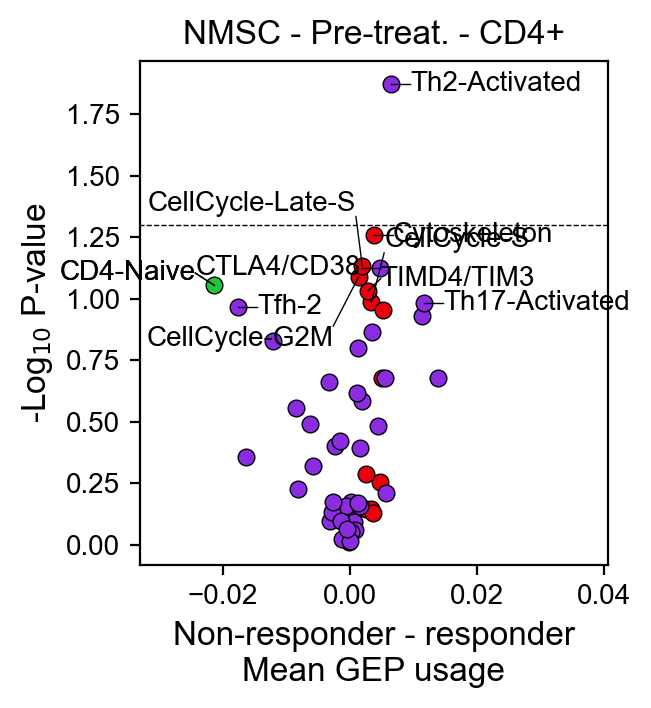

In [155]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM', 'CD4_TEMRA'])  & (adata.obs['sort'].astype(str)=='CD45+ CD3+')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_data.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'cell.id'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>4, :]

ttest_res = []
r = 'Pre'
ind = allcell_act_pct_merged['timepoint']==r
rdat = allcell_act_pct_merged.loc[ind, :]
ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

X = ttest_res.sort_values(by='P')
geps_to_plot = X.index[X['P']<.11]

xval = 'Delta'
yval = 'logP'
fs = 10

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})
ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)

ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])
ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0]-.2, xmax=xlim[1]+.2, linestyle='--', zorder=-5, color='k', lw=.5)
ax.set_xlim(xlim)


for i,g in enumerate(list(geps_to_plot) + ['CD4-Naive']):
    #lab = shorten_map[g]
    lab = g


    
    if g in ['CTLA4/CD38',   'IEG3']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['CellCycle-S',]: deltax = .002; deltay = .2; ha='left'; va='bottom' ## Upper-right

    elif g in ['ICOS/CD38',]: deltax = .002; deltay = .1; ha='left'; va='bottom' ## Upper-right
    elif g in ['TIMD4/TIM3', 'MAIT']: deltax = .002; deltay = .05; ha='left'; va='center' ## Upper-right
    elif g in ['RGCC/MYADM']: deltax = .006; deltay = .1; ha='center'; va='bottom' ## Upper-right

    
    elif g in []: deltax = 0.02; deltay = -.3; ha='center'; va='top' ## Lower-right
    elif g in [ 'HLA',]: deltax = -0.01; deltay =-0.17; ha='right'; va='top' ## Lower-Left
    elif g in [ 'CellCycle-G2M', ]: deltax = -0.004; deltay =-0.2; ha='right'; va='top' ## Lower-Left

    elif g in [ 'Th22', 'IEG3',]: deltax = 0.00; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in []: deltax = 0.003; deltay =-0.1; ha='center'; va='top' ## Below

    elif g in ['CellCycle-Late-S',]: deltax = -0.001; deltay =0.2; ha='right'; va='bottom' ## Upper-Left
    elif g in ['CD4-Naive']: deltax = -0.003; deltay =0.05; ha='right'; va='center' ## Upper-Left

    elif g in []: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)


ax.set_title('NMSC - Pre-treat. - CD4+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)
ax.set_xlim([xlim[0]-.01, xlim[1]+.025])

plt.savefig(os.path.join(figdir, 'CD4_NMSC_PreTimes_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD4_NMSC_PreTimes_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD4_nmsc_usage_pre_gep_association.tsv'), sep='\t')

ttest_res_pre = ttest_res

In [156]:
ttest_res.sort_values(by='P').head(20)

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
Th2-Activated,Th2-Activated,2.951418,0.013337,0.006406,0.508456,1.874952,0.293747,1.874952
Cytoskeleton,Cytoskeleton,2.303804,0.055168,0.003674,0.508456,1.258313,0.293747,1.258313
CellCycle-Late-S,CellCycle-Late-S,2.064251,0.073388,0.001903,0.508456,1.134376,0.293747,1.134376
CTLA4/CD38,CTLA4/CD38,1.974267,0.074802,0.004776,0.508456,1.126089,0.293747,1.126089
CellCycle-G2M,CellCycle-G2M,2.000555,0.081556,0.001324,0.508456,1.088545,0.293747,1.088545
CD4-Naive,CD4-Naive,-1.980388,0.088193,-0.021390,0.508456,1.054564,0.293747,-1.054564
TIMD4/TIM3,TIMD4/TIM3,1.928584,0.092946,0.002800,0.508456,1.031769,0.293747,1.031769
CellCycle-S,CellCycle-S,1.798330,0.103236,0.003350,0.508456,0.986167,0.293747,0.986167
Th17-Activated,Th17-Activated,1.779520,0.104046,0.011638,0.508456,0.982775,0.293747,0.982775


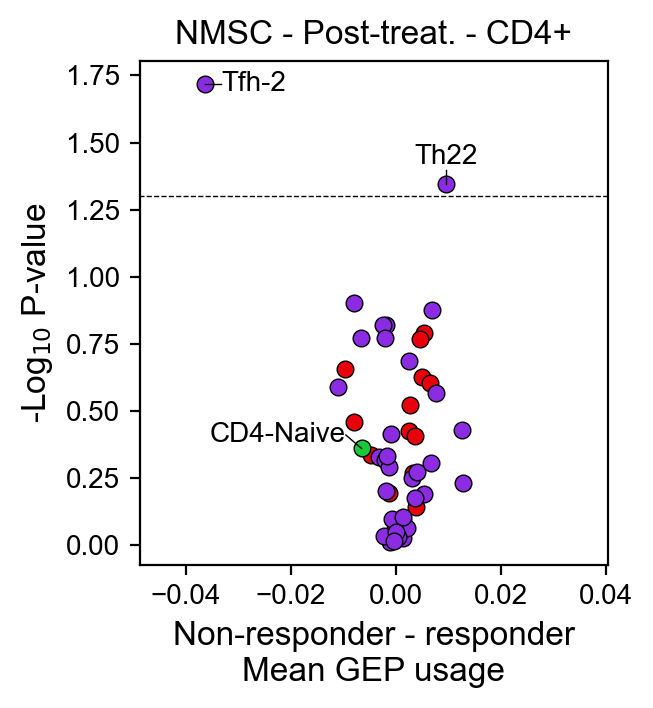

In [157]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM', 'CD4_TEMRA'])  & (adata.obs['sort'].astype(str)=='CD45+ CD3+')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_data.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'cell.id'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>4, :]

ttest_res = []
r = 'Post'
ind = allcell_act_pct_merged['timepoint']==r
rdat = allcell_act_pct_merged.loc[ind, :]
ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

X = ttest_res.sort_values(by='P')
geps_to_plot = X.index[X['P']<.11]

xval = 'Delta'
yval = 'logP'
fs = 10

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})
ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)

ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])
ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0]-.2, xmax=xlim[1]+.2, linestyle='--', zorder=-5, color='k', lw=.5)
ax.set_xlim(xlim)


for i,g in enumerate(list(geps_to_plot) + ['CD4-Naive']):
    #lab = shorten_map[g]
    lab = g


    
    if g in ['CTLA4/CD38',   'IEG3']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['CellCycle-S',]: deltax = .002; deltay = .2; ha='left'; va='bottom' ## Upper-right

    elif g in ['ICOS/CD38',]: deltax = .002; deltay = .1; ha='left'; va='bottom' ## Upper-right
    elif g in ['TIMD4/TIM3', 'MAIT']: deltax = .002; deltay = .05; ha='left'; va='center' ## Upper-right
    elif g in ['RGCC/MYADM']: deltax = .006; deltay = .1; ha='center'; va='bottom' ## Upper-right

    
    elif g in []: deltax = 0.02; deltay = -.3; ha='center'; va='top' ## Lower-right
    elif g in [ 'HLA',]: deltax = -0.01; deltay =-0.17; ha='right'; va='top' ## Lower-Left
    elif g in [ 'CellCycle-G2M', ]: deltax = -0.004; deltay =-0.2; ha='right'; va='top' ## Lower-Left

    elif g in [ 'Th22', 'IEG3',]: deltax = 0.00; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in []: deltax = 0.003; deltay =-0.1; ha='center'; va='top' ## Below

    elif g in ['CellCycle-Late-S',]: deltax = -0.001; deltay =0.1; ha='right'; va='bottom' ## Upper-Left
    elif g in ['CD4-Naive']: deltax = -0.003; deltay =0.05; ha='right'; va='center' ## Upper-Left

    elif g in []: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)


ax.set_title('NMSC - Post-treat. - CD4+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)
ax.set_xlim([xlim[0]-.01, xlim[1]+.025])

plt.savefig(os.path.join(figdir, 'CD4_NMSC_PostTimes_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD4_NMSC_PostTimes_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD4_nmsc_usage_post_gep_association.tsv'), sep='\t')

ttest_res_post = ttest_res

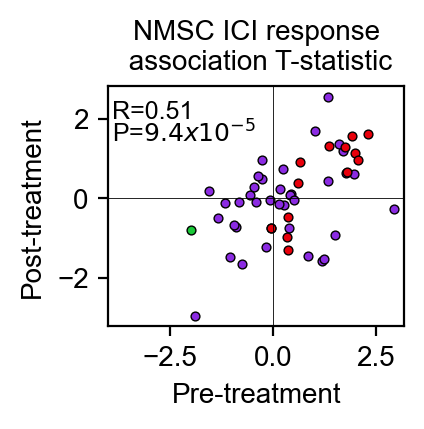

In [159]:
from scipy.stats import binom, pearsonr, fisher_exact

(fig,ax) = plt.subplots(1,1, figsize=(2,2), dpi=200, gridspec_kw={'left':.25, 'right':.99, 'bottom':.2, 'top':.8})

ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)
ax.scatter(ttest_res_pre.loc[ind2, 'T'], ttest_res_post.loc[ind2, 'T'], s=10, edgecolor='k', lw=.5,color=sns.color_palette("bright")[2])
ax.scatter(ttest_res_pre.loc[ind3, 'T'], ttest_res_post.loc[ind3, 'T'], s=10, edgecolor='k', lw=.5,color=sns.color_palette("bright")[4])
ax.scatter(ttest_res_pre.loc[ind1, 'T'], ttest_res_post.loc[ind1, 'T'], s=10, edgecolor='k', lw=.5,color=sns.color_palette("bright")[3])


xlim = ax.get_xlim()
ylim = ax.get_ylim()
xlim = (-4, xlim[1])
ax.hlines(y=0, xmin=xlim[0], xmax=xlim[1], color='k', lw=.3)
ax.vlines(x=0, ymin=ylim[0], ymax=ylim[1], color='k', lw=.3)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Pre-treatment', fontsize=10)
ax.set_ylabel('Post-treatment', fontsize=10)
ax.set_title('NMSC ICI response\n association T-statistic', fontsize=10)
R,P = pearsonr(ttest_res_pre['T'], ttest_res_post['T'])
Pstr = ('P=$%.1e' % P).replace('e-0', 'x10^{-') +'}$'
ax.text(-3.9, 2, f'R={R:.2}', fontsize=9)
ax.text(-3.9, 1.4, Pstr, fontsize=9)
plt.savefig(os.path.join(figdir, 'CD4_NMSC_PreVsPost_Scatter.png'))
plt.savefig(os.path.join(figdir, 'CD4_NMSC_PreVsPost_Scatter.pdf'))

In [160]:
ct = pd.crosstab((ttest_res_pre['P']<.05) & (ttest_res_pre['T']>0), (ttest_res_post['P']<.1) & (ttest_res_post['T']>0))
ct

col_0,False,True
row_0,,
False,50,1
True,1,0


In [161]:
fisher_exact(ct)

SignificanceResult(statistic=0.0, pvalue=1.0)

In [167]:
melanoma_pos_cd8 = ['CellCycle-G2M', 'HLA', 'ISG', 'NME1/FABP5', 'CellCycle-Late-S',
       'Metallothionein', 'TIMD4/TIM3', 'ICOS/CD38', 'OX40/EBI3',
       'Exhaustion']

melanoma_neg_cd8 = ['CD4-Naive', 'Poor-Quality', 'CD8-Naive', 'Doublet-Plasmablast']

melanoma_un_cd8 = ['Translation', 'Mito', 'Doublet-RBC', 'gdT', 'CellCycle-S', 'Cytotoxic',
       'Doublet-Platelet', 'Th22', 'MAIT', 'Cytoskeleton', 'Heatshock',
       'Multi-Cytokine', 'TEMRA', 'Doublet-Myeloid', 'CD4-CM', 'IEG', 'CD8-EM',
       'IEG2', 'Treg', 'Th17-Resting', 'RGCC/MYADM', 'BCL2/FAM13A',
       'IL10/IL19', 'Th2-Activated', 'Th2-Resting', 'Doublet-Bcell',
       'Th1-Like', 'CTLA4/CD38', 'CD8-Trm', 'Th17-Activated', 'Tfh-2',
       'CD172a/MERTK', 'IEG3', 'Doublet-Fibroblast', 'SOX4/TOX2',
       'CD40LG/TXNIP', 'Tph', 'Tfh-1']

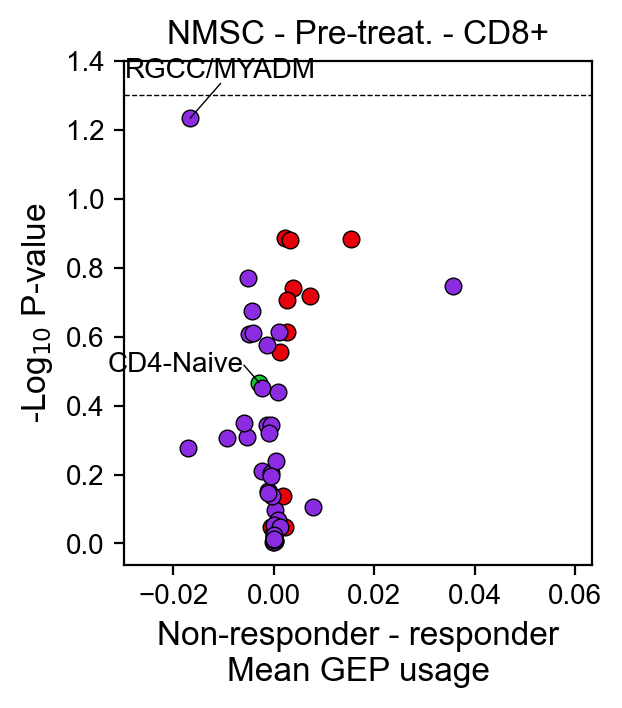

In [165]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD8_Naive', 'CD8_CM', 'CD8_EM', 'CD8_TEMRA']) & (adata.obs['sort'].astype(str)=='CD45+ CD3+')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_data.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'cell.id'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>4, :]

ttest_res = []
r = 'Pre'
ind = allcell_act_pct_merged['timepoint']==r
rdat = allcell_act_pct_merged.loc[ind, :]
ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

X = ttest_res.sort_values(by='P')
geps_to_plot = X.index[X['P']<.11]

xval = 'Delta'
yval = 'logP'
fs = 10

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})
ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)

ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])
ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0]-.2, xmax=xlim[1]+.2, linestyle='--', zorder=-5, color='k', lw=.5)
ax.set_xlim(xlim)


for i,g in enumerate(list(geps_to_plot) + ['CD4-Naive']):
    #lab = shorten_map[g]
    lab = g


    
    if g in ['CTLA4/CD38',   'IEG3']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['CellCycle-S',]: deltax = .002; deltay = .2; ha='left'; va='bottom' ## Upper-right

    elif g in ['ICOS/CD38',]: deltax = .002; deltay = .1; ha='left'; va='bottom' ## Upper-right
    elif g in ['TIMD4/TIM3', 'MAIT']: deltax = .002; deltay = .05; ha='left'; va='center' ## Upper-right
    elif g in ['RGCC/MYADM']: deltax = .006; deltay = .1; ha='center'; va='bottom' ## Upper-right

    
    elif g in []: deltax = 0.02; deltay = -.3; ha='center'; va='top' ## Lower-right
    elif g in [ 'HLA',]: deltax = -0.01; deltay =-0.17; ha='right'; va='top' ## Lower-Left
    elif g in [ 'CellCycle-G2M', ]: deltax = -0.004; deltay =-0.2; ha='right'; va='top' ## Lower-Left

    elif g in [ 'Th22', 'IEG3',]: deltax = 0.00; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in []: deltax = 0.003; deltay =-0.1; ha='center'; va='top' ## Below

    elif g in ['CellCycle-Late-S',]: deltax = -0.001; deltay =0.1; ha='right'; va='bottom' ## Upper-Left
    elif g in ['CD4-Naive']: deltax = -0.003; deltay =0.05; ha='right'; va='center' ## Upper-Left

    elif g in []: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)


ax.set_title('NMSC - Pre-treat. - CD8+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)
ax.set_xlim([xlim[0]-.01, xlim[1]+.025])

plt.savefig(os.path.join(figdir, 'CD8_NMSC_PreTimes_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD8_NMSC_PreTimes_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD8_nmsc_usage_pre_gep_association.tsv'), sep='\t')